# Bayesian Inference I
# Bayesian Inference

This article is part of a series, listed below:
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20I%20-%20Discrete%20Distributions.ipynb">Probability I - Discrete Distributions</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20II%20-%20Continuous%20Distributions.ipynb">Probability II - Continuous Distributions</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20III%20-%20Bayesian_Inference.ipynb">Probability III - Bayesian Inference</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20IV%20-%20Gaussian%20Processes.ipynb">Probability IV - Gaussian Processes</a>

## Outline

- Two Schools of Thought
- Bayesian Data Analysis
- MLE vs. Maximum a Priori (MAP)
- Model Comparison
- Choosing a Prior
- Approximation Methods
- Implementation
- Application: Switch-Point Analysis
- Application: Bayesian Networks
- References

<h2 id="two_schools">Two Schools of Thought</h2>

Bayesian inference utilizes a subset of statistical methods that are based on Bayes' Theorem, which describes the probability of an event based on knowledge of conditions related to the event. Whereas frequentist methods focus on the likelihood of observed data under fixed parameters, Bayesian methods can incorporate prior knowledge or beliefs, updating these beliefs in light of new evidence to yield 'posterior' probability distributions. This ability to inject prior beliefs is what some find controversial.

One could argue that the Bayesian analysis becomes subjective, and dependent upon the researcher. But one could also argue that not biasing the outcome, when there is prior knowledge to exploit, is an erroneous bias toward indifference. Perhaps Bayesian statistics is the generalization upon which frequentist statistics should be viewed as a subset.

-----
<i>"Newcomers to Bayesian data analysis are sometimes suspicious of using a prior distribution because they have heard rumors that a presumptuous prior can be smuggled into an analysis and thereby yield any desired posterior distribution. Prior distributions have also been accused of giving unscrupulous analysts extra degrees of freedom for finagling questionable research practices."</i>
- Bayesian Analysis for Newcomers, J. Kruschke (2017)
-----

One could argue that frequentists make strong assumptions as well. The frequentist approach tends to be heavily reliant upon the Central Limit Theorem, and the degree to which this theorem will practically apply will vary.

-----
<i>"The frequentist approach requires that all probabilities be defined by connection to the frequencies of events in very large samples. This leads to frequentist uncertainty being premised on imaginary resampling of data. Parameters and models cannot have probability distributions, only measurements can."</i>
- Statistical Rethinking (2019)

-----

<i>"Frequentist approaches rely on sampling distributions, illustrated by the cloud of imaginary possibilities... The sampling distribution is defined by the stopping and testing intuitions of the researcher. There, for any fixed set of data, different stopping or testing interactions yield different p-values and confidence intervals. Moreover, confidence intervals have no distributed information."</i>
- The Bayesian New Statistics (2017)
-----

A larger sample size will likely better satisfy the frequentist assumptions, but one can argue that when the sample size is large, finer-pointed questions which segment the data should be asked. A short blog post by author Andrew Gelman entitled "N is never enough" reads:

-----
<i>"Sample sizes are never large. If N is too small to get a sufficiently-precise estimate, you need to get more data (or make more assumptions). But once N is "large enough", you can start subdividing the data to learn more (for example, in a public opinion poll, once you have a good estimate for the entire country, you can estimate among men and women, northerners and southerners, different age groups, etc.). N is never enough because if it were "enough" you’d already be on to the next problem for which you need more data."</i>
- Andrew Gelman (2005)
-----

Furthermore, the Bayesian approach, which is more complex (though aided by computers), returns a more informative result: a posterior probability distribution, rather than a point estimate. Bayesian methods provide probablistic statements about hypotheses, models, and parameters, making it easier to make probablistic inferences and decisions.

Perhaps these are the two main arguments for Bayesian thinking. If you do not choose your prior, then one is being chosen for you (you are free to choose an uninformative one if appropriate), and the insight returned is richer. Many professors seem to express that Bayesian is simply synonymous with "better", but better in a limited context, because a) it is true the priors can be unreasonably chosen (we'll assume sound judgement going forward), b) because it is more difficult (or intractable) mathematically, and c) because it is more compute-intensive.

Modern technology is overcoming the computational hurdles, and in fact, Bayesian methods have had something to give back to computer science in the sense that such statistical methods can improve the efficiency of optimization algorithms for black-box models, through their ability to account for uncertainty, and thereby make more informed steps toward the optimum.

<h2 id="bayesian_analysis">Bayesian Data Analysis</h2>

#### Bayes Theorem

Bayes' Theorem is used to update the probability for a hypothesis, dependent upon related conditions.

$P(A|B) = \frac{P(B|A)(P(A)}{P(B)}$

Nothing is controversial about this mathematical formulation, as it follows directly from the law of conditional probability.

$P(A \cap B) = P(A|B)P(B) = P(B|A)P(A)$

#### Conditioning

Assume you have a sample of observations $y_1, \ldots, y_n$ of a random variable $Y \sim f(y|\theta)$, where $\theta$ is a parameter for the distribution. We can consider $\theta$ a random variable as well, and write:</p>

$
f(\theta|y)
= \frac{ f(y|\theta) f(\theta) }{ f(y) }
= \frac{ f(y|\theta) f(\theta) }{ \int f(y|\theta) f(\theta) ~d \theta }
$

$f(\theta|y)$ is the resulting posterior distribution. $f(y|\theta)$ is called the likelihood, and reflects the observed data. $f(\theta)$ is the prior, which multiplies against the likelihood. $f(y)$ is a normalizing constant called the evidence, or marginal likelihood, and though it can be difficult or impossible to compute in practice, we have robust approximation methods. We also often have the option to drop that term and focus on the proportionality of the numerator to the posterior.

$f(\theta|y) \propto likelihood \times prior$

#### Marginalization


To make predictions, compute the evidence, or handle nuisance parameters, we marginalize over the parameters. If we have a joint probability distribution $P(X,Y)$, the marginal distribution of $X$ is obtained by summing or interating out $Y$.

- If $Y$is discrete: $P(X) = \sum_y P(X,Y)$

- If $Y$is continuous: $P(X) = \int P(X,Y) ~dY$

Conditioning and marginalization form the backbone of Bayesian data analysis, enabling us to update our knowledge and predictions based on observed data.

<h2 id="mle_vs_map">MLE vs. Maximum a Priori (MAP)</h2>

Density estimation includes selecting a probability distribution function, and the parameters of that function which best explain the joint probability of the observed data. Often, estimating the density is challenging, so we are happy with a point estimate. Two common approaches to this are maximum likelihood estimation (MLE), a frequentist method, and maximum a posteriori (MAP), a Bayesian method.
        
With MLE, the focus is on the data at hand, without considering prior distributions. It aims to maximize the likelihood of observed data given a set of fixed parameters.

$\hat{\theta}_{MLE} = \text{argmax}_{\theta} L(\theta; X) = \text{argmax}_{\theta} \prod_{i=1}^n p(x_i | \theta)$

The Bayesian analog is maximum a priori (MAP) estimation, which seeks to find the parameter values that maximize the likelihood of the posterior distribution. It incorporates both the likelihood of the data and prior beliefs about the distribution and parameters.

$\hat{\theta}_{MAP} = \text{argmax}_{\theta} [ L(\theta;X) p(\theta) ] = \text{argmax}_{\theta} p(\theta | X) = \arg \max_{\theta} \left( \prod_{i=1}^n p(x_i | \theta) p(\theta) \right)$

-----
<i>"Maximum a posteriori (MAP) learning selects a single most likely hypothesis given the data. The hypothesis prior is still used and the method is often more tractable than full Bayesian learning."
- Artificial Intelligence: A Modern Approach (2009)</i>

-----

<i>"The maximum likelihood hypothesis might not be the MAP hypothesis, but if one assumes uniform prior probabilities over the hypothesis then it is."</i>
- Machine Learning (1997)
-----

<i>"The addition of the prior to the MLE can be thought of as a type of regularization of the MLE calculation."</i>
- Probability for Machine Learning (2021)
-----

<h2 id="model_comp">Model Comparison</h2>

Model comparison is a critical aspect of statistical analysis. Bayesian model comparison leverages the entire probability distribution of the data given the model, integrating over parameter values to account for uncertainty comprehensively. Posterior predictive checks are important toward evaluating model fit by comparing observed data to data simulated from the posterior predictive distribution. There also ana array of metrics with frequentist analogs, which speak toward model fit by comparing observed data to data simulated from a posterior predictive distribution.


#### Bayes Factors

Bayes factors quantify evidence for one model over another comparing their marginal likelihoods.

$BF = \frac{P(D|M_1)}{P(D|M_2)}$

Harold Jeffreys proposed a scale for their interpretation, with levels of support or strength:

<table class="tableizer-table">
<thead><tr class="tableizer-firstrow"><th>Bayes Factor</th><th>Support</th></tr></thead><tbody>
 <tr><td>1 - 3</td><td>Anecdotal</td></tr>
 <tr><td>3 - 10</td><td>Moderate</td></tr>
 <tr><td>10 - 30</td><td>Strong</td></tr>
 <tr><td>30 - 100</td><td>Very Strong</td></tr>
 <tr><td>>100</td><td>Extreme</td></tr>
</tbody></table>

The frequentist analog would be the likelihood ratio of two different models.

#### Bayesian Information Criterion (BIC)

The BIC approximates the marginal likelihood while penalizing model complexity (the number of paramters).

$BIC = -2 ~ln P(D|\hat{\theta},M) + k ~ln ~n$

- $\hat{\theta}$ is the maximum likelihood estimate of parameters
- $k$ is the number of parameters
- $n$ is the number of observations

The frequentist analog is the Akaike Information Criterion (AIC)

$AIC = -2 ~ln ~L(\hat{\theta}) + 2k$

- $L(\hat{\theta})$ is the MLE estimate
- $k$ is the number of parameters


#### Bayesian p-Values (BPV)

To obtain a Bayesian p-value, a summary statistic $T$, such as the mean, median, or standard deviation, $T_{obs}$ is calculated for the observed data and $T_{sim}$ for the simulated data. We ask "what is the probability that $T_{sim}$ is less than or equal to $T_{obs}$?" If the observed values agree with the predicted ones, the expected value will be $0.5$, meaning that half of the predictions will be below the observations and half will be above.

$BPV = P(T_{sim} \lt P(T_{obs} | Y))$

With frequentist p-values, the p-value is the rate of type I error (false alarms) and the goal of the decision threshold is to limit false alarms. It indicates nothing about the estimated magnitude of parameters, nor how uncertain the estimate is. What is Bayesian about the BPV is that we are not using a sampling distribution, but the posterior predictions distribution; and not a null hypothesis test, but a direct quantification of how well the model explains the data.

------
<i>"Frequentist approaches rely on sampling distributions, illustrated by the cloud of imaginary possibilities... The sampling distribution is defined by the stopping and testing intuitions of the researcher. There, for any fixed set of data, different stopping or testing interactions yield different p-values and CIs. Moreover, CIs have no distributed information."</i>
- The Bayesian New Statistics (2017)
-----

#### Highest Density Estimate

A convenient way to summarize the uncertainty is with the $95\%$ highest density interval (HDI), or interval of another arbitrary percentage. Although the frequentist CI and Bayesian HDI can have similar numerical limits, the frequentist CI is highly sensitive to the stopping and testing intuitions. By contrast, the Bayesian posterior distribution does not change when the stopping or testing intuitions change because there is no sampling distribution involved.

-----
<i>"The frequentist confidence interval is often misinterpreted as if it were a posterior distribution, because what analysts intuitively want from their analysis is the Bayesian posterior distribution."</i>
- The Bayesian New Statistics (2007)
-----

#### Multiple Comparisons

A frequentist would want to correct their p-values and confidence intervals when doing multiple comparisons. When more tests are conducted, the cloud of simulated statistics expands, enlarging the p-value for every test. Bayesian analysis, on the other hand, does not set decision thresholds on the basis of false alarm rates, and instead, considers only the posterior distribution based on actual data. False alarms can occur, but because they are caused by rogue data.


#### Outliers

Most traditional models of metric data assume that the data are normally distributed. If the data have severe outliers relative to a normal distribution, conventional practice is to transform the data or to remove the outliers from the data. Transforming data has limitations, and removing data is selecting the data to fit the model. If the outlying values are authentic representations of the underlying population, removing them constitutes selection bias and artifically reduces variances in the data. Bayesian software makes it easy to use non-normal distributions to model the data.

<h2 id="choosing_prior">Choosing a Prior</h2>

Prior elicitation is the process by which a suitable prior distribution is constructed, and though it can involve implementing data-based priors, such as determining hyperparameters for the prior from sample data using methods like MLE (empirical Bayes), this can be seen as double-dipping upon the likelihood presented by the data.

A diffuse, or non-informative prior, is designed to have minimal influence over the posterior distribution. These are sometimes referred to as objective priors. This is appropriate when little or no prior knowledge is available. Weakly informative priors provide some information, but are not overly restrictive, and are also known as regularizing priors.

-----
<i>"Regularization often take the form of a term penalizing certain values for the parameters in a model, like too-big coefficients in a regression model. Restricting parameter values is a way of reducing the data a model can represent, thus reducing the chance that a model will capture noise instead of signal. From the Bayesian point of view, Ridge regression can be interpreted as using Normal distributions for the $\beta$ coefficients of a linear model, with a small standard deviation that pushes the coefficients toward zero... on the other hand, Lasso can be interpreted from a Bayesian point of view as the MAP of the posterior computed from a model with Laplace priors for the $\beta$ coefficients."</i>
- Bayesian Analysis with Python (2024)
-----

Informative priors incorporate substantial prior knowledge about the parameter, and are used when such information is available. This can include expert knowledge based priors, or conjugate priors, which simplify the computation of posteriors because the prior and likelihood are of the same family of distributions.

#### Conjugate Priors

A conjugate prior is a prior which, when combined with a particular likelihood function, yields a posterior distribution that belongs to the same family as the prior. This simplifies the mathematical derivation of the posterior. Conjugate priors also lead to a closed-form solution for the posterior distribution, and reduce computational burden.

As an example, the Binomial likelihood with a Beta prior can be described as:

- Prior: $\theta \sim Beta(\alpha, \beta)$
- Likelihood: $P(D|\theta) - \theta^x (1-\theta)^{n-x}$
- Posterior: $\theta|D \sim Beta(\alpha + x. \beta + n - x)$

and the Poisson likelihood with a Gamma prior looks like:
- Prior: $\lambda \sim Gamma(\alpha, \beta)$
- Likelihood: $P(D|\lambda) = \frac{\lambda^x e^{-\lambda}}{x!}$, where x is the observed count
- Posterior: $\lambda \sim Gamma(\alpha + x, \beta + 1)$

A more exhaustive list is contained in the following articles:
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20I%20-%20Discrete%20Distributions.ipynb">Discrete Distributions</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20II%20-%20Continuous%20Distributions.ipynb">Continuous Distributions</a>

<h2 id="approx_methods">Approximation Methods</h2>

Markov Chain Monte Carlo (MCMC) methods generate samples from a probability distribution by constructing a <a href="https://en.wikipedia.org/wiki/Markov_chain">Markov chain</a> that has the desired distribution as its equilibrium. The idea is to design a Markov chain whose states correspond to possible values of the variable being sampled, and whose stationary distribution is the target distribution. Hamiltonian Monte Carlo (HMC) leverages concepts from physics, using gradient information about the target distribution to explore the parameter space more efficiently. No-U-Turn Sampling (NUTS) is a popular form of HMC that further enhances efficiency and usability by automatically adjusting the trajectory length and step size.

A good resource for additional information on MCMC sampling is chapter 9 of Statistical Rethinking by Richard McElreath.

<h2 id="implementation">Implementation</h2>

Let's consider a Bernoulli experiment with a Beta prior that is uniform (the Beta is a generalization of the Uniform). Consider it analogous to an unfair coin flip, as I will set the probability of a positive outcome to 0.4. We'll call upon the <code>beta</code> function of the <code>scipy.stats</code> module to create a Beta distribution (the default parameters of which will result in the Uniform).

Within a loop through experiments of different sample sizes, we will call upon the <code>bernoulli.rvs</code> function of the same module to generate random data, using our pre-specified of 0.4 as the probability of positive otucome. We will then update the prior, the Beta distribution, to have parameters which reflect a multiplication with the observed likelihood of the experiment. Of course, the result will converge toward the true parameter value as the sample size grows.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from IPython.core.pylabtools import figsize

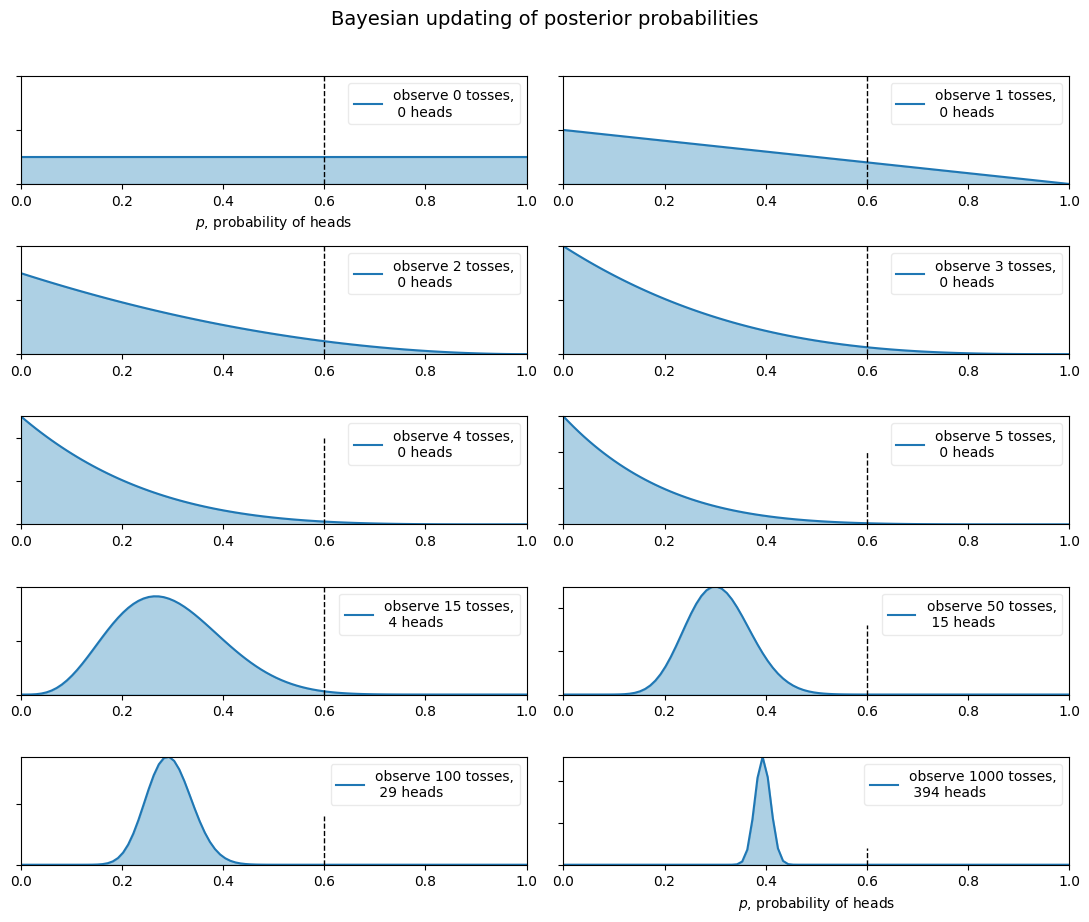

In [ ]:
# the following code is from Bayesian Methods for Hackers

figsize(11, 9)

import scipy.stats as stats

dist = stats.beta
n_trials = [0, 1, 2, 3, 4, 5, 15, 50, 100, 1000]
data = stats.bernoulli.rvs(0.4, size=n_trials[-1])
x = np.linspace(0, 1, 100)

for k, N in enumerate(n_trials):
    sx = plt.subplot(len(n_trials)//2, 2, k+1)
    plt.xlabel("$p$, probability of heads") \
        if k in [0, len(n_trials)-1] else None
    plt.setp(sx.get_yticklabels(), visible=False)
    heads = data[:N].sum()
    y = dist.pdf(x, 1 + heads, 1 + N - heads)
    plt.plot(x, y, label="observe %d tosses,\n %d heads" % (N, heads))
    plt.fill_between(x, 0, y, color="#348ABD", alpha=0.4)
    plt.vlines(0.6, 0, 4, color="k", linestyles="--", lw=1)

    leg = plt.legend()
    leg.get_frame().set_alpha(0.4)
    plt.autoscale(tight=True)


plt.suptitle("Bayesian updating of posterior probabilities",
             y=1.02,
             fontsize=14)

plt.tight_layout()

There are many applications for Bayesian analysis, this article will cover a couple - namely, switch-point analysis and Bayesian networks. The switch-point analysis will be accomplished in Python using the PyMC package, and the Bayesian network will be coded in R using the bnlearn package.

<h2 id="switch_pt">Application: Switch-Point Analysis</h2>

Suppose we have a time-series of data and suspect (or want to investigate) whether the distribution parameters have shifted over time. In the below example from Bayesian Methods for Hackers, Cam Davidson-Pilon applies this analysis to text message counts over a span of 75 days, using a Poisson process, as this is appropriate for count data.

Let's assume that on some day $\tau$ during the observation period, the parameter $\lambda$ suddenly jumps to a higher value. The transition period is called a switchpoint.

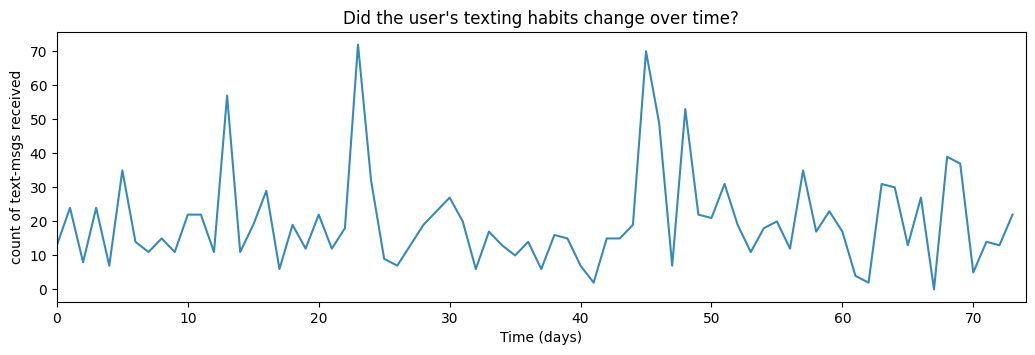

In [ ]:
# the following code is from Bayesian Methods for Hackers

figsize(12.5, 3.5)
count_data = np.loadtxt("txtdata.csv")
n_count_data = len(count_data)
plt.plot(np.arange(n_count_data), count_data, color="#348ABD")
plt.xlabel("Time (days)")
plt.ylabel("count of text-msgs received")
plt.title("Did the user's texting habits change over time?")
plt.xlim(0, n_count_data);

We are interested in inferring the unkonwn $\lambda$'s. A good choice of probability distribution for these variables would be the Exponential, as it provides a continuous density function for positive numbers.

- $\lambda_1 \sim Expo(\alpha)$
- $\lambda_2 \sim Expo(\alpha)$

The expected value is $\frac{1}{\alpha}$.

It's difficult to predict where $\tau$ might have occurred, so we'll use a discrete Uniform distribution as the prior.

The function <code>lambda_</code> represents the random variable <code>\lambda</code>. The switch function assigns <code>lambda_1</code> or <code>lambda_2</code> to <code>lambda_</code>, depending on which side of <code>tau</code> we are on.

In [ ]:
import pymc as pm

with pm.Model() as model:
    alpha = 1.0/count_data.mean()
    lambda_1 = pm.Exponential("lambda_1", alpha)
    lambda_2 = pm.Exponential("lambda_2", alpha)

    tau = pm.DiscreteUniform("tau", lower=0, upper=n_count_data - 1)

    idx = np.arange(n_count_data) # Index
    lambda_ = pm.math.switch(tau > idx, lambda_1, lambda_2)
    observation = pm.Poisson("obs", lambda_, observed=count_data)

The variable <code>observation</code> combines our data with our proposed data-generation scheme. PyMC provides the nifty capability to visualize the structure of our model as follows:

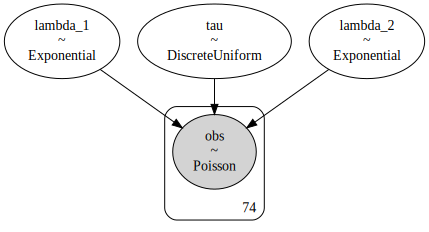

In [ ]:
pm.model_to_graphviz(model)

<img src="img/model.png" style="height: 300px; width:auto;">

The capability exists to create far more complicated models, and to set variables to deterministic if wanting them to be fully determined by the parent variables.

The below code returns thousands of random variables from the posterior distributions of $\lambda_1$, $\lambda_2$, and $\tau$. We can plot a histogram of the random variables to see what the posterior distributions look like.

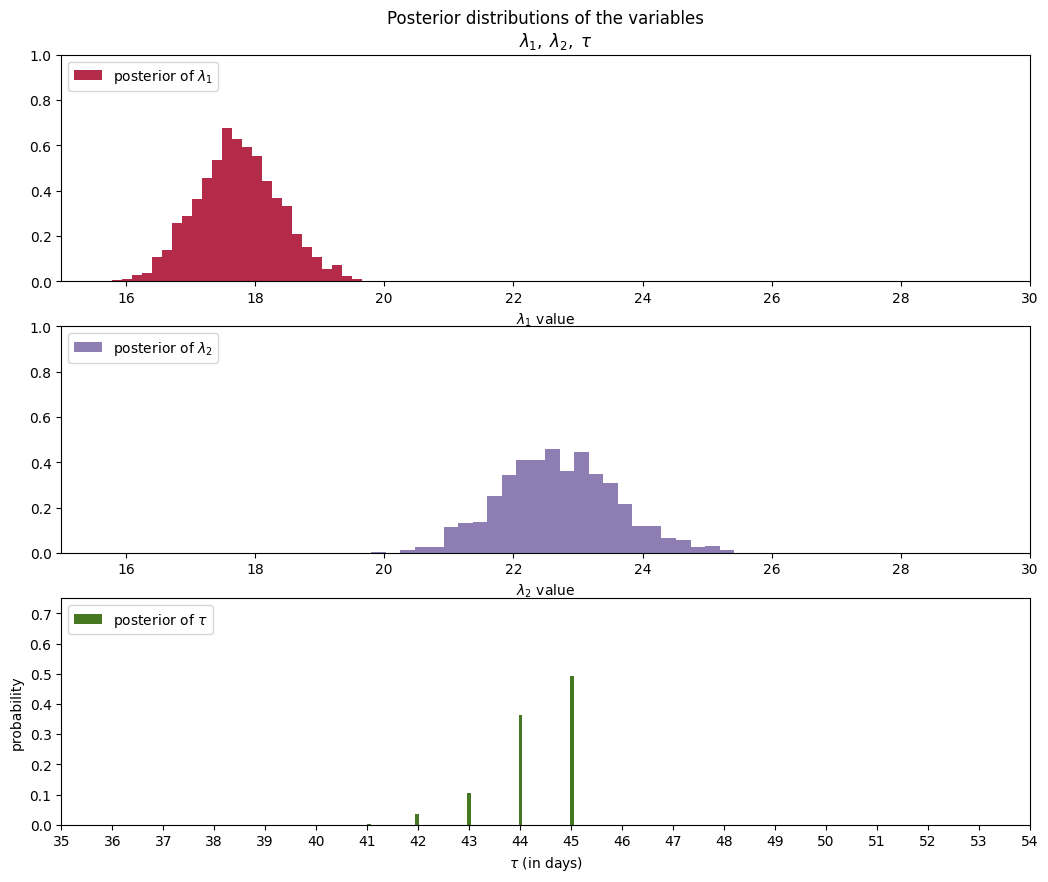

In [ ]:
with model:
    step = pm.Metropolis()
    trace = pm.sample(10000, tune=5000, step=step, return_inferencedata=False)

lambda_1_samples = trace['lambda_1']
lambda_2_samples = trace['lambda_2']
tau_samples = trace['tau']

figsize(12.5, 10)
ax = plt.subplot(311)
ax.set_autoscaley_on(False)

plt.hist(lambda_1_samples, histtype='stepfilled', bins=30, alpha=0.85,
         label="posterior of $\lambda_1$", color="#A60628", density=True)
plt.legend(loc="upper left")
plt.title(r"""Posterior distributions of the variables
    $\lambda_1,\;\lambda_2,\;\tau$""")
plt.xlim([15, 30])
plt.xlabel("$\lambda_1$ value")

ax = plt.subplot(312)
ax.set_autoscaley_on(False)
plt.hist(lambda_2_samples, histtype='stepfilled', bins=30, alpha=0.85,
         label="posterior of $\lambda_2$", color="#7A68A6", density=True)
plt.legend(loc="upper left")
plt.xlim([15, 30])
plt.xlabel("$\lambda_2$ value")

plt.subplot(313)
w = 1.0 / tau_samples.shape[0] * np.ones_like(tau_samples)
plt.hist(tau_samples, bins=n_count_data, alpha=1,
         label=r"posterior of $\tau$",
         color="#467821", weights=w, rwidth=2.)
plt.xticks(np.arange(n_count_data))

plt.legend(loc="upper left")
plt.ylim([0, .75])
plt.xlim([35, len(count_data)-20])
plt.xlabel(r"$\tau$ (in days)")
plt.ylabel("probability");

We now have distributions to describe the unknown $\lambda$'s and $\tau$. The posterior distributions of the two $\lambda$'s are clearly distinct, indicating there was a change in the number of defects.

-----
<i>"Bayesian inference is concerned with beliefs... Rather than try to guess $\lambda$ exactly, we can only talk about what $\lambda$ is likely to be by assigning a probability distribution... This might seem odd... How can we assign probabilities to values of a non-random variable? Ah, we have fallen for our old, frequentist way of thinking. Recall that under the Bayesian philosophy, we can assign probabilities if we interpret them as beliefs. And it is entirely acceptable to have beliefs about the parameter."</i>
- Bayesian Methods for Hackers
-----

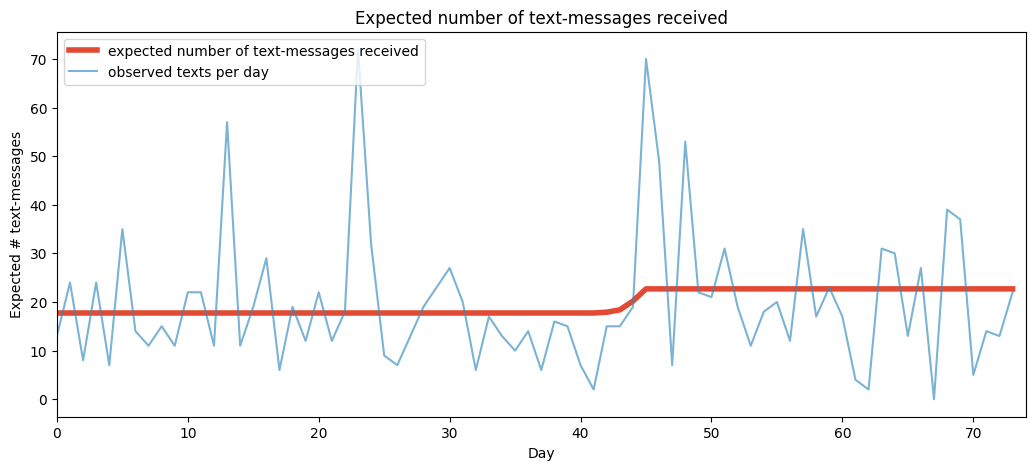

In [ ]:
figsize(12.5, 5)
N = tau_samples.shape[0]
expected_texts_per_day = np.zeros(n_count_data)

for day in range(0, n_count_data):
    ix = day < tau_samples
    expected_texts_per_day[day] = (lambda_1_samples[ix].sum()
                                   + lambda_2_samples[~ix].sum()) / N

plt.plot(range(n_count_data), expected_texts_per_day, lw=4, color="#E24A33",
         label="expected number of text-messages received")
plt.xlim(0, n_count_data)
plt.xlabel("Day")
plt.ylabel("Expected # text-messages")
plt.title("Expected number of text-messages received")
# plt.ylim(0, 60)
plt.plot(np.arange(len(count_data)), count_data, color="#348ABD", alpha=0.65,
        label="observed texts per day")

plt.legend(loc="upper left");

<h2 id="bn">Application: Bayesian Networks</h2>

Probablistic graphical models (PGMs) are a framework for representing and reasoning about complex joint distributions among random variables, facilitating efficient computation and enabling sophisticated inference and learning techniques. In the graph structure, there are nodes, which represent random variables, and edges, which represent conditional dependencies. Directed graphical models such as Bayesian Networks (BNs) use directed edges to represent the direction of dependence, and undirected graphical models such as Markov Random Fields use undirected edges to represent mutual dependence.

A Bayesian Network allows you to leverage domain expertise, reducing the number of variable interactions by choosing how the network is structured. In other words, we decide which variables will influence each other, be independent, or be conditionally independent. Generally, the topology is created by hand.

However, it is quite possible that we neither know the network structure nor have the domain knowledge to construct the network. In the case of knowledge discovery, we would like to learn the dependencies between variables. Several methods may be employed, such as:

- Constraint-Based Structure Learning: we consider a Bayesian network to be a set of dependencies between random variables, and try to find these dependence conditions based on the data. One major drawback is that if we get a wrong result from our dependence tests, our whole learning fails.

- Score-Based Structure Learning: we consider the random variable a statistical model, and define a hypothesis space of possible structures and a scoring function that tells us how close our structure is to the underlying structure. As this method considers the whole model at once, it is able to give better results than constraint-based learning. A drawback is that the hypothesis space can be very large, making it hard to find the optimal structure.

- Bayesian Model Averaging: we learn many structures, and then use an ensemble of all these structures. The number of network structures can be huge, so we may need to use approximation methods.

#### Implementation

The popular R libarary <code>bnlearn</code> has been under continuous development for over a decade, and includes several examples of implementations on their website. One of the more interesting ones, which also provides the data, is provided by the authors of the paper <a href="https://doi.org/10.1038/s41598-017-15293-w">"Bayesian Networks Analysis of Malocclusion Data"</a>. A malocclusion is a misalignment between the teeth of the upper and lower dental arches as the jaws close.

The code was executed in an R notebook over Google Colab, and imported into this one via a copy/paste operation. To execute the following yourself, you will need to be in the R environment rather than Python.

The metrics are somewhat esoteric, if like myself, you are not in the dental or orthodontic business, but we are provided with the following feature definitions:

- <code>ID</code>: anonymised ID code unique to each patient.
- <code>Treatment</code>: untreated (NT), treated with bad results (TB), treated with good results (TG).
- <code>Growth</code>: a binary variable with values Good or Bad, determined on the basis of CoGn-CoA.
- <code>ANB</code>: angle between Down's points A and B (degrees).
- <code>IMPA</code>: incisor-mandibular plane angle (degrees).
- <code>PPPM</code>: palatal plane - mandibular plane angle (degrees).
- <code>CoA</code>: total maxillary length from condilion to Down's point A (mm).
- <code>GoPg</code>: length of mandibular body from gonion to pogonion (mm).
- <code>CoGo</code>: length of mandibular ramus from condilion to pogonion (mm).

Each variable has a <code>T1</code> and <code>T2</code> measurement, expressing the age of the patient at the 'before' vs. 'after' measurements. <code>T1</code> and <code>T2</code> are also available as variables themselves.

The data can be loaded from the following links:
- https://www.bnlearn.com/research/scirep17/prepd-ortho.rda
- https://www.bnlearn.com/research/scirep17/prepd-bathia.rda

First, we'll import and inspect the data.

In [ ]:
load("prepd-ortho.rda")
str(ortho)

'data.frame':	143 obs. of  17 variables:
 $ ID       : Factor w/ 143 levels "P001","P002",..: 1 2 4 5 6 7 9 10 11 13 ...
 $ Treatment: Factor w/ 3 levels "NT","TB","TG": 1 1 1 1 1 1 1 1 3 1 ...
 $ Growth   : Factor w/ 2 levels "Bad","Good": 1 2 1 1 1 2 2 2 1 1 ...
 $ ANB      : num  -5.2 -1.7 -3.1 -1.3 0.4 1.5 -0.1 0.5 0.2 0.2 ...
 $ IMPA     : num  75.9 77.2 89.8 98.7 90.5 96.9 85.9 92 91.7 82.2 ...
 $ PPPM     : num  30.2 27 19.8 21.5 26.5 25.2 21.2 19.5 31.1 22.7 ...
 $ CoA      : num  83.4 91.3 78.6 96.4 83.3 88 85 77.1 88.8 77.5 ...
 $ GoPg     : num  77.9 84.1 67.3 75.6 74.7 72.8 75.2 65.2 76.2 67.8 ...
 $ CoGo     : num  50.1 59.2 50.4 65.7 51.3 58 54.9 44.8 53.3 44.5 ...
 $ ANB2     : num  -8.4 -2.3 -4.7 -2.4 -0.7 0.9 -1.3 0.4 0.8 -2.8 ...
 $ IMPA2    : num  71.7 81 83.8 86.6 83.8 95.8 87.7 93.6 92.3 82.6 ...
 $ PPPM2    : num  29.1 26.5 16.7 19.4 26.5 24.3 19.4 17.2 30.2 20.1 ...
 $ CoA2     : num  84.4 93.9 82.9 110.5 91 ...
 $ GoPg2    : num  81.9 84 71.5 96.3 83.5 71.8 76.9

In [ ]:
load("prepd-bathia.rda")

Then, calculate the differences between the before and after measurements for each variable at the patient level.

In [ ]:
diff = data.frame(
dANB = ortho$ANB2 - ortho$ANB,
dPPPM = ortho$PPPM2 - ortho$PPPM,
dIMPA = ortho$IMPA2 - ortho$IMPA,
dCoA = ortho$CoA2 - ortho$CoA,
dGoPg = ortho$GoPg2 - ortho$GoPg,
dCoGo = ortho$CoGo2 - ortho$CoGo,
dT = ortho$T2 - ortho$T1,
Growth = as.numeric(ortho$Growth) - 1,
Treatment = as.numeric(ortho$Treatment != "NT")
)

<code>Growth</code> and <code>Treatment</code> together carry redundant information about the prognosis, so <code>Treatment</code> is re-coded as a binary variable for which 1 means either TB (treatment with bad results) or TG (treatment with good results), and 0 means NT (no treatment). Growth is encoded such that 0 means bad and 2 means good.

In [ ]:
table(ortho[, c("Treatment", "Growth")])

         Growth
Treatment Bad Good
       NT  51   26
       TB  10    3
       TG  24   29

In [ ]:
table(diff[, c("Treatment", "Growth")])

         Growth
Treatment  0  1
        0 51 26
        1 34 32

The authors intend to leverage correlation (and domain knowledge) to determine the connections and their directions. The plot below provides a correlation matrix, and hierarchical clustering based on Euclidean distance, which also offers an interesting way to think about relationships and directions.

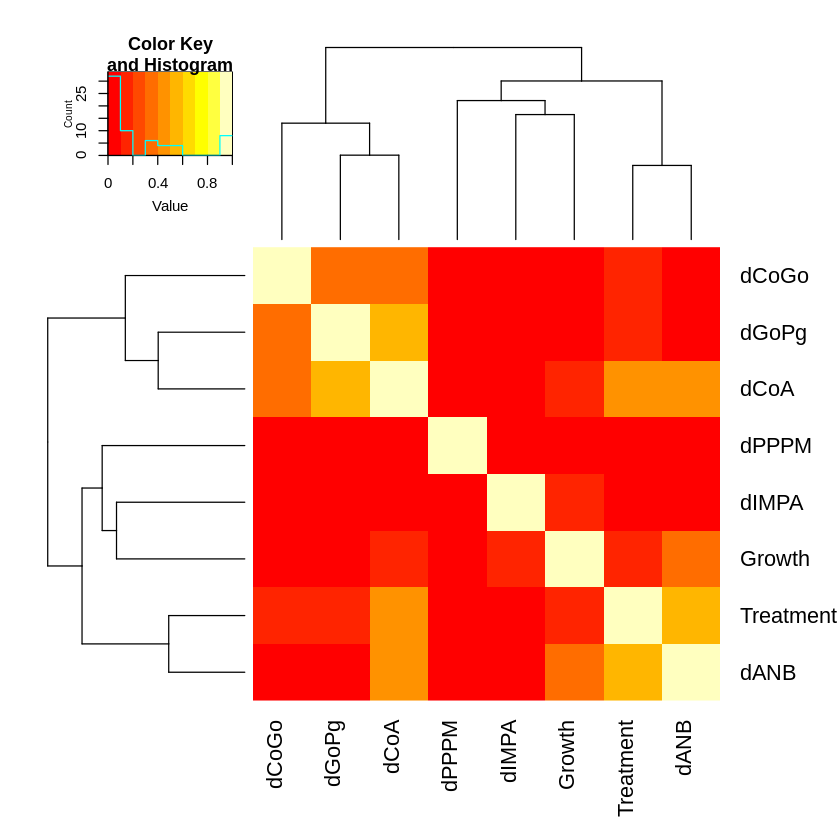

In [ ]:
library(gplots)
diff.delta = sapply(diff[, 1:6], function(x) x / diff$dT)
rho = cor(data.frame(diff.delta, Growth = diff$Growth, Treatment = diff$Treatment))
palette.breaks = seq(0, 1, 0.1)
par(oma=c(2,2,2,1))
heatmap.2(rho, scale = "none", trace = "none", revC = TRUE, breaks = palette.breaks)

The following network is simply focused on nodes where correlations are greater than 40%.

Loading required namespace: Rgraphviz



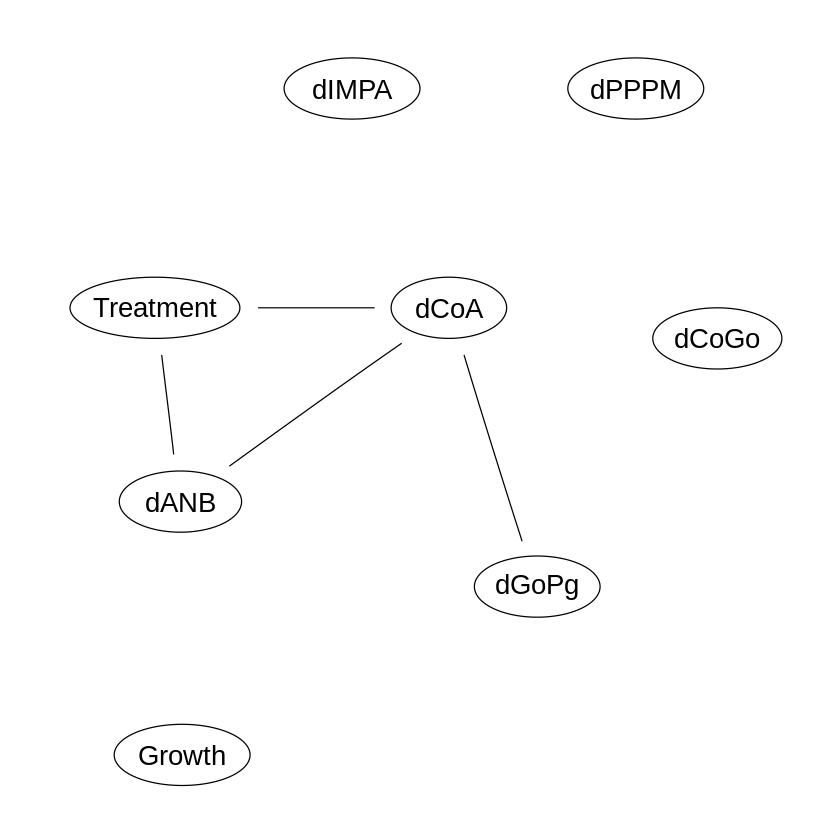

In [ ]:
library(bnlearn)

ug = empty.graph(colnames(rho))
amat(ug) = (rho > 0.4) + 0L - diag(1L, nrow(rho))
graphviz.plot(ug, layout = "fdp", shape = "ellipse")

The next network will incorporate domain knowledge through a whitelist and blacklist of connections.

-----
<ul><i>
    <li>We blacklist any arc pointing to <code>dT</code>, <code>Treatment</code> and <code>Growth</code> from the orthodontic variables.</li>
    <li>We blacklist any arc from <code>dT</code> and <code>Treatment</code>. This means that whether a patient is treated does not change over time.</li>
    <li>We whitelist the dependence structure <code>dANB</code> → <code>dIMPA</code> ← <code>dPPPM</code>.</li>
    <li>We whitelist the arc from <code>dT</code> to <code>Growth</code> which allows the prognosis to change over time.</li></i>
</ul>
- <a href="https://www.bnlearn.com/research/scirep17/">https://www.bnlearn.com/research/scirep17/</a>

-----

The network consensus model is constructed by learning 200 networks from the data and keeping the arcs that appear at least 50% of the time. The direction of the arcs seem to be well established, which can probably be attributed to the whitelist and blacklist.

-----
<i>"Arcs in red are constrained to be present in the network by the whitelist. The thickness of the arcs is in proportion to their strength; only arcs with strength greater than 0.5 are included in the consensus network".</i>
- <a href="https://doi.org/10.1038/s41598-017-15293-w">Bayesian Networks Analysis of Malocclusion Data (2007)</a>
----- 

In [ ]:
bl = tiers2blacklist(list("dT", "Treatment", "Growth",
       c("dANB", "dPPPM", "dIMPA", "dCoA", "dGoPg", "dCoGo")))
bl = rbind(bl, c("dT", "Treatment"), c("Treatment", "dT"))
wl = matrix(c("dANB", "dIMPA",
              "dPPPM", "dIMPA",
              "dT", "Growth"),
        ncol = 2, byrow = TRUE, dimnames = list(NULL, c("from", "to")))

In [ ]:
str.raw = boot.strength(diff, R = 200, algorithm = "hc",
            algorithm.args = list(whitelist = wl, blacklist = bl))
attr(str.raw, "threshold")
avg.raw.full = averaged.network(str.raw)

[1] 0.515

Warning message in averaged.network.backend(strength = strength, threshold = threshold):
“arc dCoA -> dCoGo would introduce cycles in the graph, ignoring.”


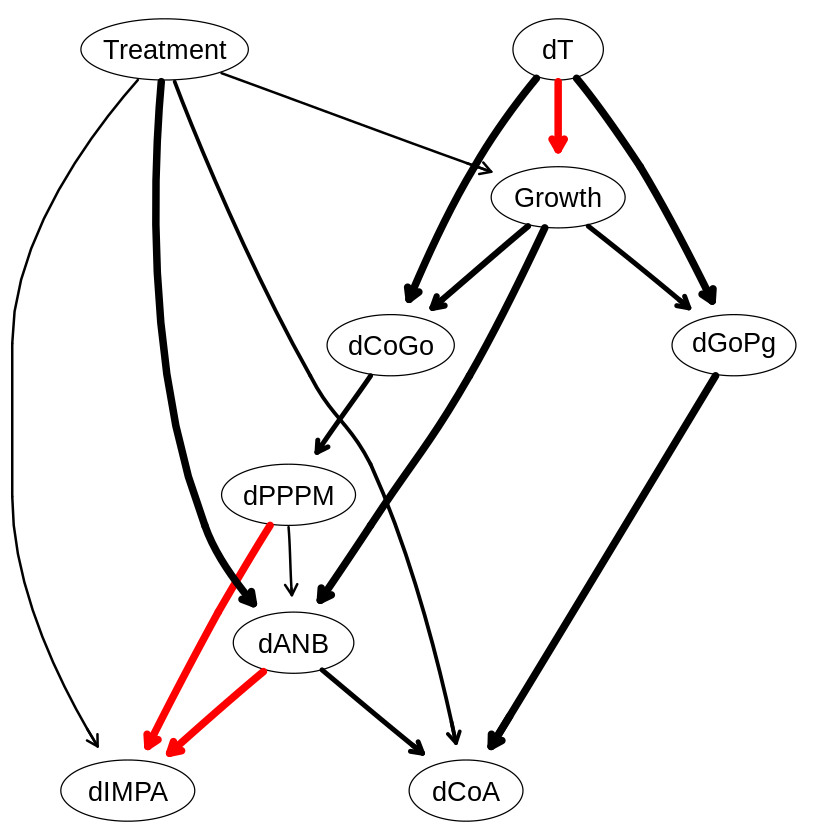

In [ ]:
strength.plot(avg.raw.full, str.raw, shape = "ellipse", highlight = list(arcs = wl))

In [ ]:
avg.raw.full$learning$whitelist = wl
avg.raw.full$learning$blacklist = bl
nrow(undirected.arcs(cpdag(avg.raw.full, wlbl = TRUE)))

[1] 0

In [ ]:
nrow(str.raw[with(str.raw, strength > 0.50 & direction > 0.50), ])

[1] 18

In [ ]:
nrow(str.raw[with(str.raw, strength > 0.85 & direction > 0.50), ])

[1] 12

The next network constrains connections to having a strength of 0.85 or greater (or being on the whitelist).

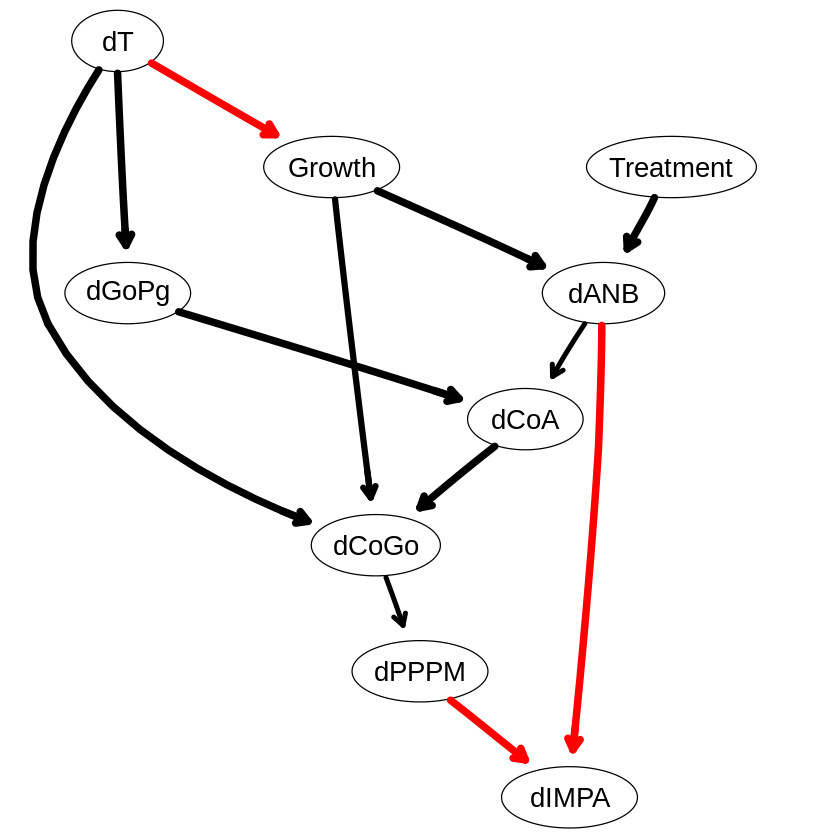

In [ ]:
avg.raw.simpler = averaged.network(str.raw, threshold = 0.85)
strength.plot(avg.raw.simpler, str.raw, shape = "ellipse", highlight = list(arcs = wl))

I suggest perusing the entire paper, and the bnlearn page, which summarizes and provides the code.

Bayesian networks are the topics of later articles in the series, however the next two are about Bayesian linear regression. The next article in the series can be found <a href="">**here**</a>.

## References

- Davidson-Pilon, C. Bayesian Methods for Hackers. https://dataorigami.net/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/#contents

- Scutari, M., Auconi, P., Caldarelli, G., & Franchi, L. (2017). Bayesian Networks Analysis of Malocclusion Data. Nature. https://doi.org/10.1038/s41598-017-15293-w

- bnlearn (n.d.). Analysis of class III malocclusion in Scutari et al., Scientific Reports (2017). Bnlearn Documentation. https://www.bnlearn.com/research/scirep17/

- Kruschke, J. K., & Liddell, T. M. (2017). The Bayesian New Statistics. Psychonomic Society. https://doi.org/10.3758/s13423-016-1221-4

- Martin, O. (2024). Bayesian Analysis with Python (3rd ed.). Packt. https://www.packtpub.com/en-ca/product/bayesian-analysis-with-python-9781805127161

- Bellot, D. (2016). Learning Probabilistic Graphical Models in R. Packt. https://www.packtpub.com/en-ca/product/learning-probabilistic-graphical-models-in-r-9781784392055

- Ankan, A., & Panda, A. (2018). Mastering Probabilistic Graphical Models with Python. Packt. https://www.packtpub.com/en-ca/product/mastering-probabilistic-graphical-models-with-python-9781784394684

- Martin, O. A., Kumar, R., & Lao, J. (2021). Bayesian Modeling and Computation in Python. CRC Press. https://doi.org/ISBN 978-0-367-89436-8

- Gelman, A., Carlin, J., Stern, H., Rubin, D., Dunson, D., & Vehtari, A. (1995). Bayesian Data Analysis (3rd ed.). https://www.researchgate.net/publication/46714374_Bayesian_data_analysis

- Barber, D. (2007). Bayesian Reasoning and Machine Learning. http://web4.cs.ucl.ac.uk/staff/D.Barber/textbook/270212.pdf

- Kruschke, J. K., & Liddell, T. M. (2017). Bayesian data analysis for newcomers. Psychonomic Society. https://doi.org/10.3758/s13423-017-1272-1

- McElreath, R. (2017). Statistical Rethinking (2nd ed.). https://github.com/Booleans/statistical-rethinking/blob/master/Statistical%20Rethinking%202nd%20Edition.pdf

- Salvatier, J., Wiecki, T. V., & Fonnesbeck, C. (2015). Probabilistic Programming in Python using PyMC. https://arxiv.org/pdf/1507.08050v1

- Van de Schoot et al., R. Bayesian statistics and modelling. Nature. https://doi.org/10.1038/ s43586-020-00001-2

- Abril-Pla, O. et al. (2023). PyMC: A modern, and comprehensive probabilistic programming framework in Python. PeerJ. https://doi.org/10.7717/peerj-cs.1516

- Orduz, J. (2013). Introduction to Bayesian Modeling with PyMC3. https://juanitorduz.github.io/intro_pymc3/

- S, O. (n.d.). Full Explanation of MLE, MAP and Bayesian Inference. https://towardsdatascience.com/full-explanation-of-mle-map-and-bayesian-inference-1db9a7fb1d2b

- (2005, July 31). N is never large. Statistical Modeling, Causal Inference, and Social Science. https://statmodeling.stat.columbia.edu/2005/07/31/n_is_never_larg/